In [19]:
import json
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Dict, Any


In [20]:
def flatten_observation(obs: Dict[str, Any], max_projects: int = 5, max_running_projects: int = 5, max_peers: int = 8) -> Dict[str, float]:
    """
    Flattens the complex observation dictionary into a flat feature vector.
    """
    flat = {}
    
    # Simple fields
    flat["accumulated_rewards"] = obs["accumulated_rewards"][0]
    flat["age"] = obs["age"][0]
    flat["peer_h_index"] = obs["peer_h_index"][0]
    
    # Peer group (Binary mask)
    for i in range(max_peers):
        flat[f"peer_active_{i}"] = obs["peer_group"][i]
        flat[f"peer_reputation_{i}"] = obs["peer_reputation"][i]
        flat[f"peer_centroid_x_{i}"] = obs["peer_centroids"][i][0]
        flat[f"peer_centroid_y_{i}"] = obs["peer_centroids"][i][1]
    
    # Self Centroid
    flat["self_centroid_x"] = obs["self_centroid"][0][0]
    flat["self_centroid_y"] = obs["self_centroid"][0][1]
    
    # Project Opportunities
    opps = obs.get("project_opportunities", {})
    for i in range(max_projects):
        key = f"project_{i}"
        if key in opps:
            p = opps[key]
            flat[f"opp_quality_effort_{i}"] = p["required_effort"][0]
            flat[f"opp_quality_prestige_{i}"] = p["prestige"][0]
            flat[f"opp_quality_novelty_{i}"] = p["novelty"][0]
            flat[f"opp_quality_time_{i}"] = p["time_window"][0]
            flat[f"opp_exists_{i}"] = 1
        else:
            flat[f"opp_quality_effort_{i}"] = 0
            flat[f"opp_quality_prestige_{i}"] = 0
            flat[f"opp_quality_novelty_{i}"] = 0
            flat[f"opp_quality_time_{i}"] = 0
            flat[f"opp_exists_{i}"] = 0
            
    # Running Projects
    running = obs.get("running_projects", {})
    # Since keys are dynamic (project IDs), we sort them or take first N
    running_keys = sorted(running.keys())
    for i in range(max_running_projects):
        if i < len(running_keys):
            p = running[running_keys[i]]
            flat[f"run_quality_effort_{i}"] = p["required_effort"][0]
            flat[f"run_quality_prestige_{i}"] = p["prestige"][0]
            flat[f"run_quality_novelty_{i}"] = p["novelty"][0]
            flat[f"run_quality_time_left_{i}"] = p["time_left"][0]
            flat[f"run_quality_current_effort_{i}"] = p["current_effort"][0]
            flat[f"run_exists_{i}"] = 1
        else:
            flat[f"run_quality_effort_{i}"] = 0
            flat[f"run_quality_prestige_{i}"] = 0
            flat[f"run_quality_novelty_{i}"] = 0
            flat[f"run_quality_time_left_{i}"] = 0
            flat[f"run_quality_current_effort_{i}"] = 0
            flat[f"run_exists_{i}"] = 0
            
    return flat

def build_global_dataframe(
    actions_path: str | Path,
    observations_path: str | Path,
    agent_id: str = "agent_0"
) -> pd.DataFrame:
    rows = []
    skipped = 0
    
    with open(actions_path, "r", encoding="utf-8") as f_act, open(observations_path, "r", encoding="utf-8") as f_obs:
        for step, (act_line, obs_line) in enumerate(zip(f_act, f_obs)):
            try:
                act = json.loads(act_line)
                obs = json.loads(obs_line)
            except json.JSONDecodeError:
                continue

            if obs is None or act is None or agent_id not in obs or agent_id not in act:
                skipped += 1
                continue
            
            agent_obs_data = obs[agent_id]
            agent_act_data = act[agent_id]
            
            if agent_obs_data is None or agent_act_data is None:
                skipped += 1
                continue
                
            # Flatten observation
            flat_obs = flatten_observation(agent_obs_data["observation"])
            
            # Action: For "global" analysis, let's look at whether any project was started
            # or whether we continued projects. Or just the choose_project action.
            # We keep the raw value of choose_project
            flat_obs["action_choose_project"] = agent_act_data.get("choose_project", 0)
            
            # Or predict if we collaborated with anyone
            collab = agent_act_data.get("collaborate_with", [])
            flat_obs["action_any_collab"] = 1 if sum(collab) > 0 else 0
            
            # Put effort analysis
            effort = agent_act_data.get("put_effort", {})
            if isinstance(effort, dict):
                flat_obs["action_any_effort"] = 1 if any(v > 0 for v in effort.values()) else 0
            else:
                flat_obs["action_any_effort"] = 1 if effort > 0 else 0
            
            rows.append(flat_obs)
            
    return pd.DataFrame(rows)


In [21]:
# Load data
seeds = range(101, 111)
log_dir = Path("../log")
reward_scheme = "by_effort"

all_dfs = []
for seed in seeds:
    act_p = log_dir / f"rl_ppo_{reward_scheme}_s{seed}_actions.jsonl"
    obs_p = log_dir / f"rl_ppo_{reward_scheme}_s{seed}_observations.jsonl"
    if act_p.exists() and obs_p.exists():
        all_dfs.append(build_global_dataframe(act_p, obs_p))

df = pd.concat(all_dfs, ignore_index=True)
print(f"Loaded {len(df)} steps")

# Filter for cases where project start is possible (opp_exists_0 == 1)
df_valid = df[df["opp_exists_0"] == 1].copy()
print(f"Filtered to {len(df_valid)} valid steps (opp_exists_0 == 1)")


Loaded 3485 steps
Filtered to 3485 valid steps (opp_exists_0 == 1)


In [22]:
# Prepare features and target
# Target: Which project was chosen? (0 = none, 1 = project_0, ...)
target_col = "action_choose_project"
X = df_valid.drop(columns=["action_choose_project", "action_any_collab", "action_any_effort"])
y = df_valid[target_col]

# Train a classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X, y)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

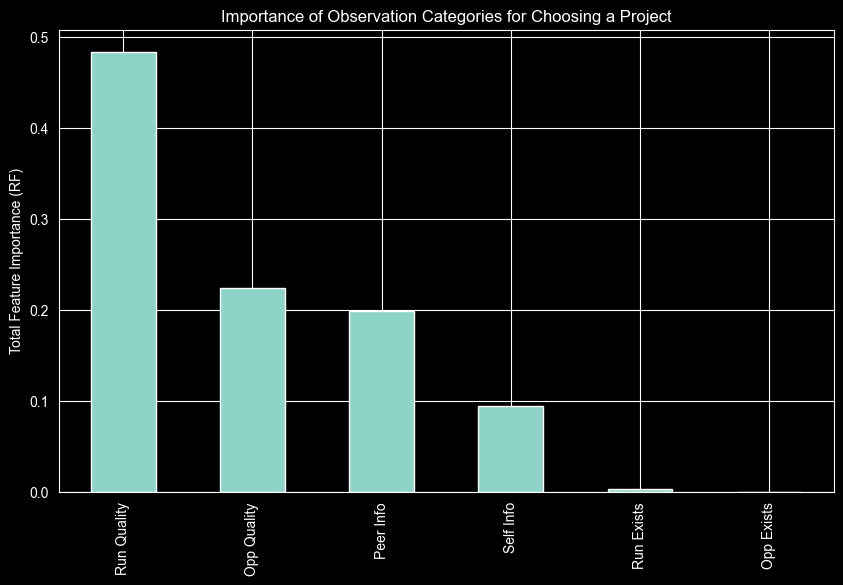

In [23]:
# Analyze Importance
importances = clf.feature_importances_
feature_names = X.columns
feat_importances = pd.Series(importances, index=feature_names)

# Group features by category
categories = {
    "Run Exists": ["run_exists_"],
    "Run Quality": ["run_quality_"],
    "Opp Exists": ["opp_exists_"],
    "Opp Quality": ["opp_quality_"],
    "Peer Info": ["peer_"],
    "Self Info": ["self_", "accumulated_rewards", "age", "peer_h_index"]
}

cat_importance = {}
for cat, prefixes in categories.items():
    cat_importance[cat] = feat_importances[feat_importances.index.str.startswith(tuple(prefixes))].sum()

cat_series = pd.Series(cat_importance).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
cat_series.plot(kind='bar')
plt.title("Importance of Observation Categories for Choosing a Project")
plt.ylabel("Total Feature Importance (RF)")
plt.show()


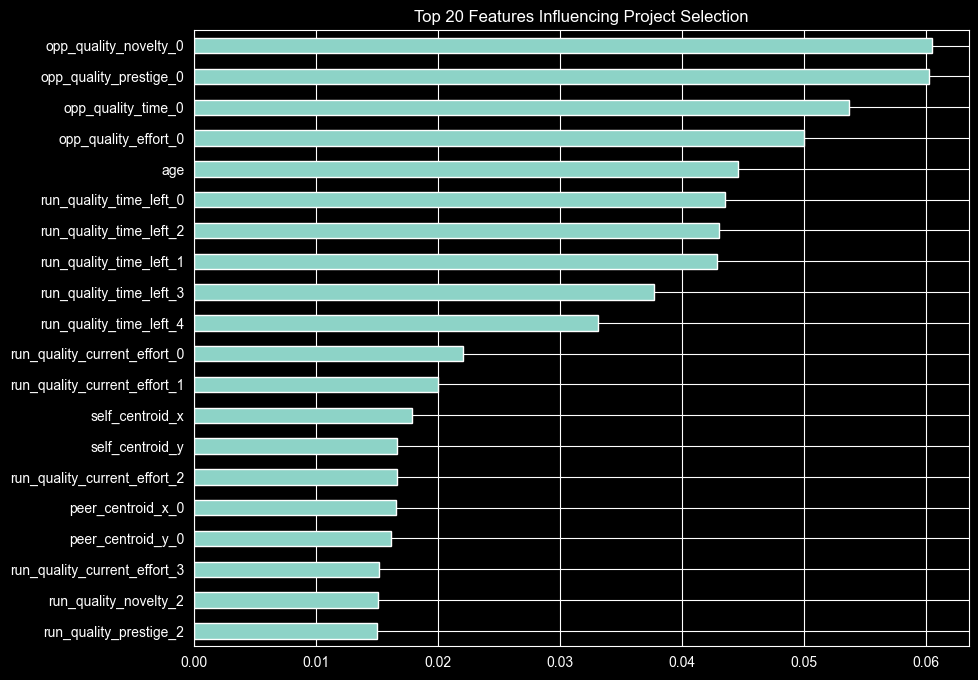

In [24]:
# Top 20 individual features
plt.figure(figsize=(10, 8))
feat_importances.nlargest(20).sort_values().plot(kind='barh')
plt.title("Top 20 Features Influencing Project Selection")
plt.show()


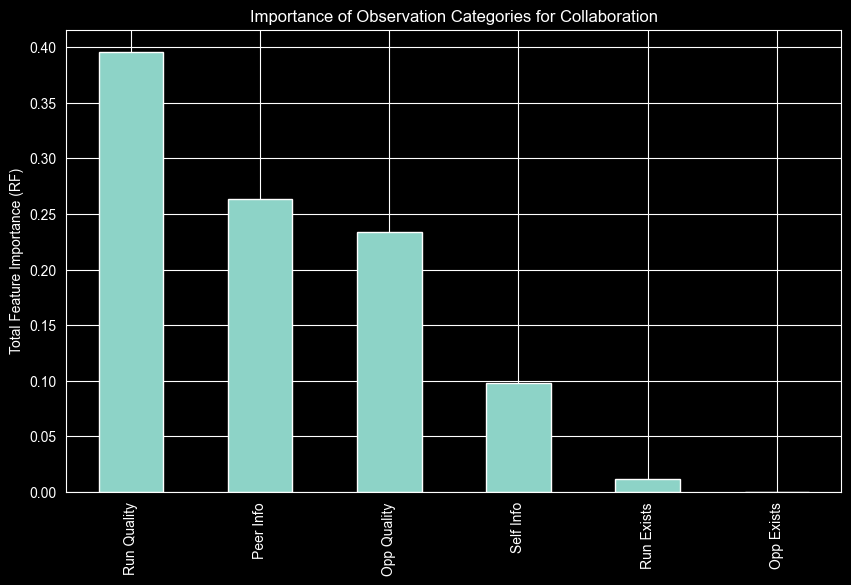

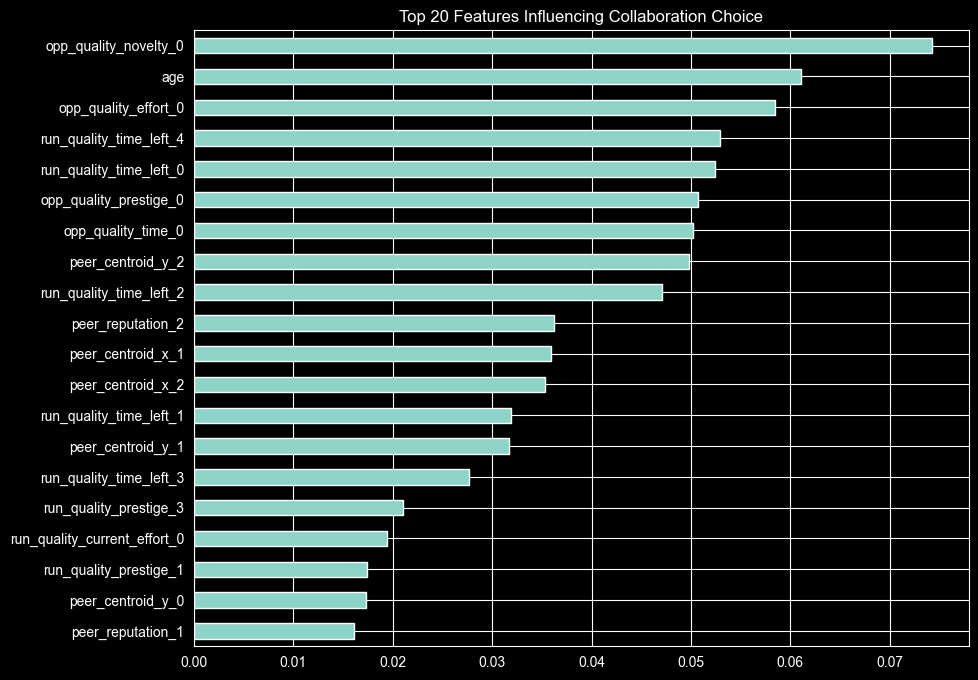

In [25]:
# Repeat for collaboration action
target_col_collab = "action_any_collab"
y_collab = df[target_col_collab]

if y_collab.nunique() > 1:
    clf_collab = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_collab.fit(X, y_collab)
    
    importances_collab = clf_collab.feature_importances_
    feat_importances_collab = pd.Series(importances_collab, index=feature_names)
    
    cat_importance_collab = {}
    for cat, prefixes in categories.items():
        cat_importance_collab[cat] = feat_importances_collab[feat_importances_collab.index.str.startswith(tuple(prefixes))].sum()

    cat_series_collab = pd.Series(cat_importance_collab).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    cat_series_collab.plot(kind='bar')
    plt.title("Importance of Observation Categories for Collaboration")
    plt.ylabel("Total Feature Importance (RF)")
    plt.show()
    
    plt.figure(figsize=(10, 8))
    feat_importances_collab.nlargest(20).sort_values().plot(kind='barh')
    plt.title("Top 20 Features Influencing Collaboration Choice")
    plt.show()
else:
    print("No variation in collaboration action.")


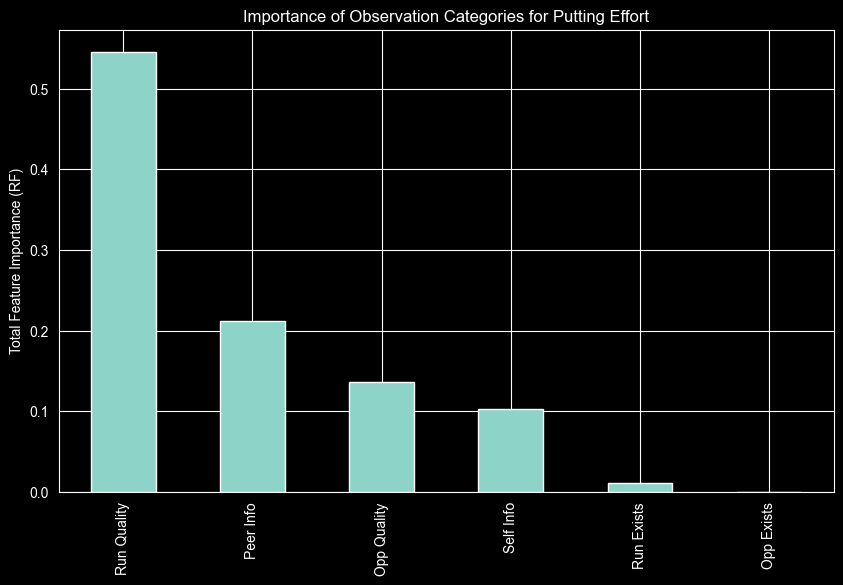

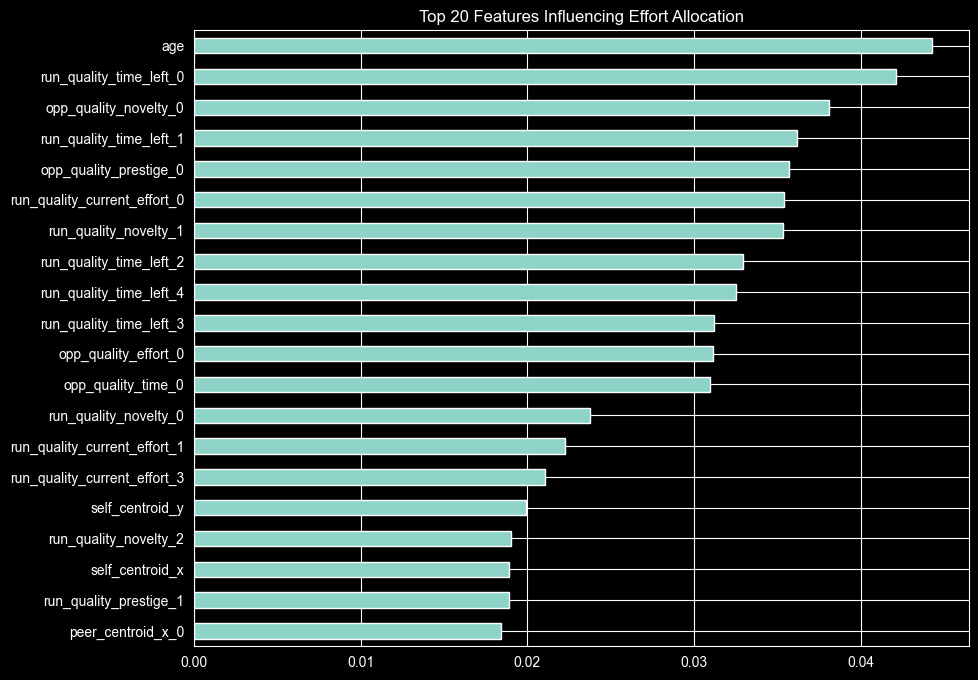

In [26]:
# Repeat for effort action
target_col_effort = "action_any_effort"
y_effort = df[target_col_effort]

if y_effort.nunique() > 1:
    clf_effort = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_effort.fit(X, y_effort)
    
    importances_effort = clf_effort.feature_importances_
    feat_importances_effort = pd.Series(importances_effort, index=feature_names)
    
    cat_importance_effort = {}
    for cat, prefixes in categories.items():
        cat_importance_effort[cat] = feat_importances_effort[feat_importances_effort.index.str.startswith(tuple(prefixes))].sum()

    cat_series_effort = pd.Series(cat_importance_effort).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    cat_series_effort.plot(kind='bar')
    plt.title("Importance of Observation Categories for Putting Effort")
    plt.ylabel("Total Feature Importance (RF)")
    plt.show()
    
    plt.figure(figsize=(10, 8))
    feat_importances_effort.nlargest(20).sort_values().plot(kind='barh')
    plt.title("Top 20 Features Influencing Effort Allocation")
    plt.show()
else:
    print("No variation in effort action.")


In [28]:
# 1. Slot-Shuffling Experiment
print("--- Experiment 1: Slot-Shuffling ---")

def shuffle_project_slots(df_orig, max_projects=5):
    df_shuffled = df_orig.copy()
    feature_groups = ["opp_quality_effort", "opp_quality_prestige", "opp_quality_novelty", "opp_quality_time", "opp_exists"]
    
    # Ensure columns have correct types to avoid TypeError: Invalid value for dtype 'int64'
    # when we try to put a float into a column that happened to be all-zeros (int64)
    for group in feature_groups:
        if group == "opp_exists":
            dtype = "int64"
        else:
            dtype = "float64"
        for idx in range(max_projects):
            col = f"{group}_{idx}"
            if col in df_shuffled.columns:
                df_shuffled[col] = df_shuffled[col].astype(dtype)

    for i in range(len(df_shuffled)):
        # Create a permutation of project indices
        perm = np.random.permutation(max_projects)
        
        # Original values for this row
        row_copy = df_shuffled.iloc[i].copy()
        
        # Mapping for the target if it's a project choice
        orig_choice = int(row_copy["action_choose_project"])
        
        # If choice was 0 (no project), it stays 0. 
        # If choice was 1..max_projects, it was project (choice-1).
        if 0 < orig_choice <= max_projects:
            orig_project_idx = orig_choice - 1
            # Where did this project move to?
            # We want to find new_idx such that perm[new_idx] == orig_project_idx
            new_project_idx = np.where(perm == orig_project_idx)[0][0]
            df_shuffled.iloc[i, df_shuffled.columns.get_loc("action_choose_project")] = new_project_idx + 1
        
        # Shuffle features
        for new_idx, old_idx in enumerate(perm):
            for group in feature_groups:
                col_old = f"{group}_{old_idx}"
                col_new = f"{group}_{new_idx}"
                df_shuffled.iloc[i, df_shuffled.columns.get_loc(col_new)] = row_copy[col_old]
                
    return df_shuffled

# Since shuffling the whole DF might be slow, let's take a sample or use df_valid
df_shuffled = shuffle_project_slots(df_valid.iloc[:500]) # Sample for speed
X_shuffled = df_shuffled.drop(columns=["action_choose_project", "action_any_collab", "action_any_effort"])
y_shuffled = df_shuffled["action_choose_project"]

score_orig = clf.score(X.loc[df_shuffled.index], df_valid.loc[df_shuffled.index, "action_choose_project"])
score_shuffled = clf.score(X_shuffled, y_shuffled)

print(f"Accuracy on original data (subset): {score_orig:.4f}")
print(f"Accuracy on shuffled slots data: {score_shuffled:.4f}")
if score_orig - score_shuffled > 0.05:
    print("Significant drop in performance -> Agent likely relies on slot position!")
else:
    print("Performance stable -> Agent likely uses content regardless of slot.")


--- Experiment 1: Slot-Shuffling ---
Accuracy on original data (subset): 1.0000
Accuracy on shuffled slots data: 0.6060
Significant drop in performance -> Agent likely relies on slot position!


In [29]:
# 2. Mask-conditioned Analysis
print("\n--- Experiment 2: Mask-conditioned Analysis ---")
# Count how many projects exist in each step
opp_exists_cols = [f"opp_exists_{i}" for i in range(5)]
num_projects = df[opp_exists_cols].sum(axis=1)

df_multi = df[num_projects > 1].copy()
print(f"Found {len(df_multi)} steps with more than 1 project available.")

if len(df_multi) > 10:
    X_multi = df_multi.drop(columns=["action_choose_project", "action_any_collab", "action_any_effort"])
    y_multi = df_multi["action_choose_project"]
    
    clf_multi = RandomForestClassifier(n_estimators=100, random_state=42)
    clf_multi.fit(X_multi, y_multi)
    
    feat_importances_multi = pd.Series(clf_multi.feature_importances_, index=X_multi.columns)
    
    plt.figure(figsize=(10, 8))
    feat_importances_multi.nlargest(20).sort_values().plot(kind='barh')
    plt.title("Top 20 Features (Steps with >1 Project)")
    plt.show()



--- Experiment 2: Mask-conditioned Analysis ---
Found 0 steps with more than 1 project available.


In [30]:
# 3. Counterfactual Analysis
print("\n--- Experiment 3: Counterfactual Analysis ---")

# Take samples where project 1 was chosen
samples = df_valid[df_valid["action_choose_project"] == 1].iloc[:10].copy()

if not samples.empty:
    cf_samples = samples.copy()
    feature_groups_quality = ["opp_quality_effort", "opp_quality_prestige", "opp_quality_novelty", "opp_quality_time"]
    
    # Swap quality of project 0 and project 1
    for group in feature_groups_quality:
        col0 = f"{group}_0"
        col1 = f"{group}_1"
        cf_samples[col0], cf_samples[col1] = samples[col1], samples[col0]
    
    X_cf = cf_samples.drop(columns=["action_choose_project", "action_any_collab", "action_any_effort"])
    preds_orig = clf.predict(X.loc[samples.index])
    preds_cf = clf.predict(X_cf)
    
    results_cf = pd.DataFrame({
        "Original Prediction": preds_orig,
        "Counterfactual Prediction": preds_cf
    })
    print("Effect of swapping Quality features between Slot 0 and Slot 1:")
    print(results_cf)
    
    changes = (preds_orig != preds_cf).sum()
    print(f"\nDecision changed in {changes} out of {len(samples)} cases.")
else:
    print("No suitable samples found for counterfactual analysis.")


--- Experiment 3: Counterfactual Analysis ---
Effect of swapping Quality features between Slot 0 and Slot 1:
   Original Prediction  Counterfactual Prediction
0                    1                          0
1                    1                          1
2                    1                          1
3                    1                          1
4                    1                          1
5                    1                          1
6                    1                          1
7                    1                          1
8                    1                          1
9                    1                          0

Decision changed in 2 out of 10 cases.
